In [ ]:
# https://dmw2166.github.io/comp-res-climate-data-sci/assignments/more_matplotlib.html

# Assignment: More Matplotlib

## Problem 1: Line plots

In [1]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2016-01-01,64756,2.422,-73.74,41.79,3.4,-0.5,1.5,1.3,0.0,1.69,...,0.233,0.204,0.155,0.147,4.2,4.4,5.1,6.0,7.6,NaN
2016-01-02,64756,2.422,-73.74,41.79,2.9,-3.6,-0.4,-0.3,0.0,6.25,...,0.227,0.199,0.152,0.144,2.8,3.1,4.2,5.7,7.4,NaN
2016-01-03,64756,2.422,-73.74,41.79,5.1,-1.8,1.6,1.1,0.0,5.69,...,0.223,0.196,0.151,0.141,2.6,2.8,3.8,5.2,7.2,NaN
2016-01-04,64756,2.422,-73.74,41.79,0.5,-14.4,-6.9,-7.5,0.0,9.17,...,0.220,0.194,0.148,0.139,1.7,2.1,3.4,4.9,6.9,NaN
2016-01-05,64756,2.422,-73.74,41.79,-5.2,-15.5,-10.3,-11.7,0.0,9.34,...,0.213,0.191,0.148,0.138,0.4,0.9,2.4,4.3,6.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,64756,2.622,-73.74,41.79,2.5,-2.1,0.2,0.3,0.0,7.50,...,0.275,0.248,0.191,0.192,1.3,1.4,1.9,3.2,4.7,NaN
2018-12-28,64756,2.622,-73.74,41.79,11.6,1.9,6.8,7.6,11.5,0.45,...,0.295,0.261,0.193,0.191,2.9,2.7,2.5,3.1,4.5,NaN
2018-12-29,64756,2.622,-73.74,41.79,11.3,-2.1,4.6,6.3,0.0,4.89,...,0.295,0.270,0.208,0.191,4.5,4.4,4.0,3.8,4.5,NaN


In [2]:
t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [3]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


In [4]:
import numpy as np
from matplotlib import pyplot as plt

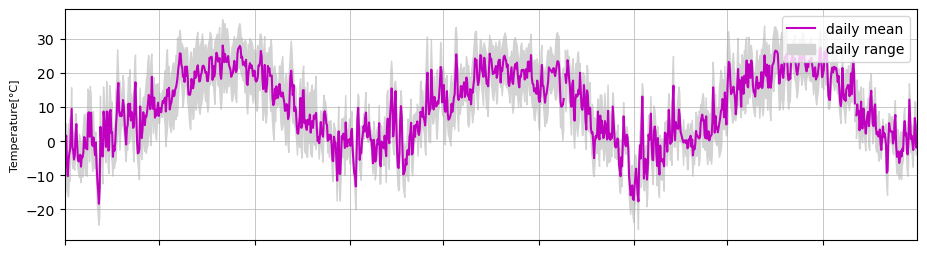

In [115]:
fig, ax = plt.subplots(figsize=(11,3))
ax.plot(date,t_daily_mean,color='m',label='daily mean')
ax.margins(x=0)
plt.fill_between(date,t_daily_min,t_daily_max,color='lightgrey',label='daily range')
ax.legend(loc='upper right')
plt.ylabel('Temperature[°C]',fontsize=8)
ax.set_xticklabels([])
ax.grid(axis='both', linewidth=0.5)

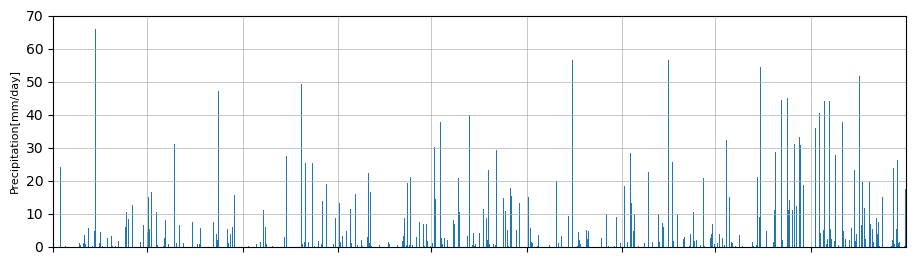

In [119]:
fig, ax = plt.subplots(figsize=(11,3))
ax.bar(date,p_daily_calc)
ax.margins(x=0)
plt.ylim(0,70)
plt.ylabel('Precipitation[mm/day]',fontsize= 8)
ax.set_xticklabels([])
ax.grid(axis='both', linewidth=0.5)

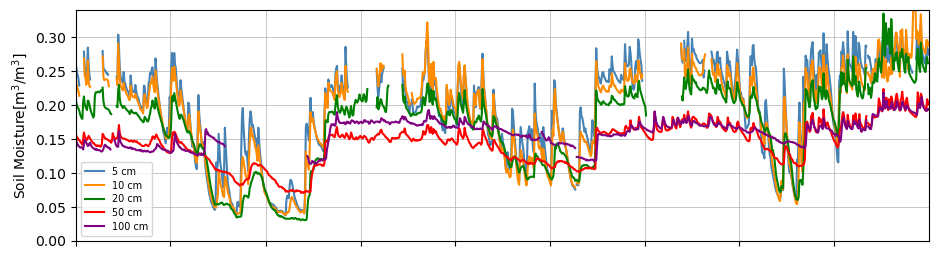

In [482]:
fig, ax = plt.subplots(figsize=(11,3))
ax.plot(date,soil_moisture_5,color='steelblue',label='5 cm')
ax.plot(date,soil_moisture_10,color='darkorange',label='10 cm')
ax.plot(date,soil_moisture_20,color='green',label='20 cm')
ax.plot(date,soil_moisture_50,color='red',label='50 cm')
ax.plot(date,soil_moisture_100,color='purple',label='100 cm')
ax.margins(x=0)
plt.ylim(0,0.34)
plt.ylabel('Soil Moisture[m$^3$/m$^3$]')
plt.legend(loc='lower left')
ax.legend(
    fontsize=7,        
    markerscale=0.8,   
    handlelength=2,
    labelspacing=0.4 )
ax.set_xticklabels([])
ax.grid(axis='both', linewidth=0.5)

## using subplot

Text(0.5, 0, 'Date')

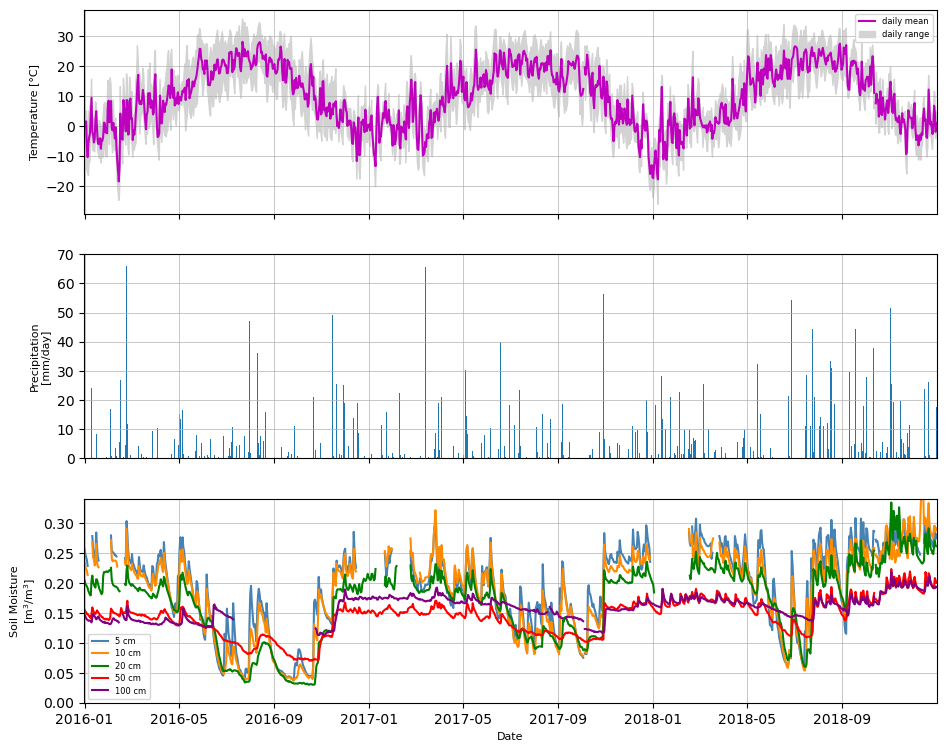

In [496]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(date, t_daily_mean, color='m', label='daily mean')
axes[0].fill_between(date, t_daily_min, t_daily_max, color='lightgrey', label='daily range')
axes[0].margins(x=0)
axes[0].set_ylabel('Temperature [°C]', fontsize=8)
axes[0].legend(loc='upper right',fontsize=6, markerscale=0.6, handlelength=2, labelspacing=0.4)
axes[0].grid(axis='both', linewidth=0.5)

axes[1].bar(date, p_daily_calc)
axes[1].margins(x=0)
axes[1].set_ylim(0, 70)
axes[1].set_ylabel('Precipitation\n[mm/day]', fontsize=8)
axes[1].grid(axis='both', linewidth=0.5)

axes[2].plot(date, soil_moisture_5, color='steelblue', label='5 cm')
axes[2].plot(date, soil_moisture_10, color='darkorange', label='10 cm')
axes[2].plot(date, soil_moisture_20, color='green', label='20 cm')
axes[2].plot(date, soil_moisture_50, color='red', label='50 cm')
axes[2].plot(date, soil_moisture_100, color='purple', label='100 cm')
axes[2].margins(x=0)
axes[2].set_ylim(0, 0.34)
axes[2].set_ylabel('Soil Moisture\n[m$^3$/m$^3$]',fontsize=8)
axes[2].legend(loc='lower left', fontsize=6, markerscale=0.6, handlelength=2, labelspacing=0.4)
axes[2].grid(axis='both', linewidth=0.5)

axes[2].set_xlabel('Date',fontsize=8)

# Problem 2: Contour Plots

In [141]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

In [142]:
temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

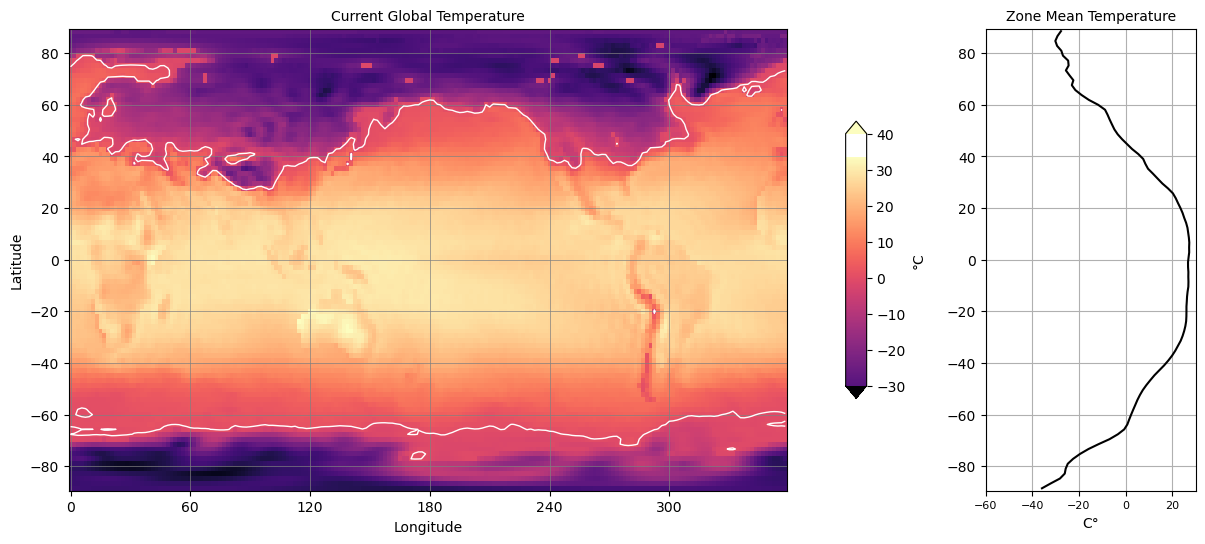

In [469]:
fig, (ax, cax, zax) = plt.subplots(1, 3, figsize=(14,6),
     gridspec_kw={'width_ratios':[10,1,4]})
fig.subplots_adjust(wspace=0.01)

cax.set_position([0.68, 0.15, 0.015, 0.7])
zax.set_position([0.78, 0.15, 0.15, 0.7])

pos = ax.get_position()
zax.set_position([0.78, pos.y0, 0.15, pos.height])

m = ax.pcolormesh(lon, lat, temp, cmap='magma', shading='auto')

cbar = fig.colorbar(m, cax=cax, label='°C', extend='both')
pos = ax.get_position()
cb_height = pos.height * 0.6
cb_bottom = pos.y0 + (pos.height - cb_height)/2
cax.set_position([0.68, cb_bottom, 0.015, cb_height])
cax.set_ylim(-30,40)

zonal_mean = np.mean(temp, axis=1)
zax.plot(zonal_mean, lat, color='black')
zax.sharey(ax)
zax.grid()
zax.set_xlim(-60,30)
zax.set_xticks([-60, -40, -20, 0, 20])
zax.tick_params(axis='x', labelsize=8)
zax.set_ylim(ax.get_ylim())
zax.set_xlabel('C°',fontsize=10)
zax.set_title('Zone Mean Temperature', fontsize= 10)

ax.set_xticks(np.arange(0,360,60))
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(color='gray', linewidth=0.5)
ax.set_title('Current Global Temperature', fontsize=10)

ax.contour(lon, lat, temp, levels=[0], colors='white', linewidths=1)

# Problem 3: Scatter plots

In [188]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

Unzipping contents of '/home/xm2357/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/xm2357/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


/tmp/ipykernel_41818/1376464035.py:2: RuntimeWarning: divide by zero encountered in log10
  logdepth = np.log10(depth)


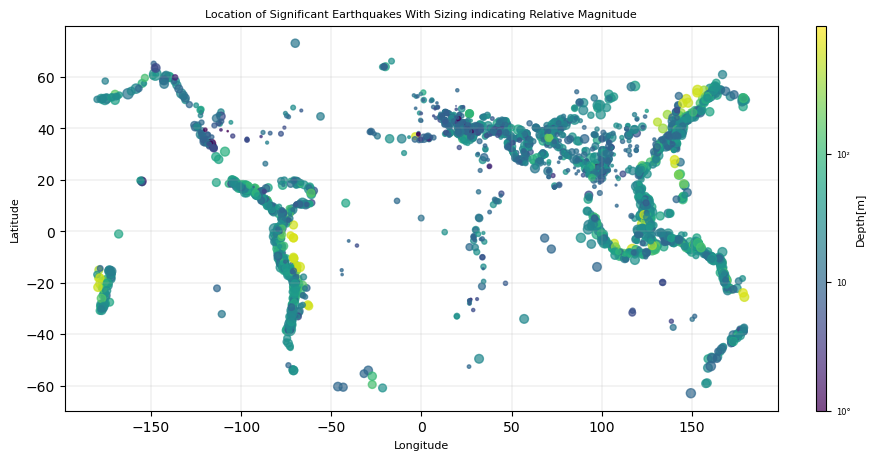

In [287]:
fig, ax = plt.subplots(figsize=(10,5))
logdepth = np.log10(depth)
eplot = ax.scatter(longitude,latitude,s=magnitude**4/100,c=logdepth,
                   cmap='viridis',vmin=0,vmax=3,
                  alpha=0.7)
cbar = fig.colorbar(eplot,fraction=0.03,aspect=40)
ticks= np.arange(0,3)
cbar.set_ticks(ticks)
cbar.set_ticklabels(['10°','10', '10²'],fontsize=6)
cbar.set_label('Depth[m]',fontsize=8)
ax.set_xlabel('Longitude',fontsize=8)
ax.set_ylabel('Latitude',fontsize=8)
ax.set_title('Location of Significant Earthquakes With Sizing indicating Relative Magnitude',fontsize=8)
plt.grid(linewidth=0.2)